# Tratar dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dfTest = pd.read_csv('test_data.csv',encoding='latin1')
dfTrain = pd.read_csv('training_data.csv',encoding='latin1')

In [3]:
dfTest.head()

,city_name,record_date,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_PRECIPITATION,AVERAGE_RAIN
0,Porto,2019-02-13 23:00:00,39.2,0.0,91.0,DARK,8.0,1026.0,71.0,1.0,céu claro,0.0,NaN
1,Porto,2018-11-28 20:00:00,42.5,12.2,76.8,DARK,11.0,1020.0,93.0,4.0,nuvens dispersas,0.0,NaN
2,Porto,2018-08-14 05:00:00,45.9,0.0,86.3,DARK,14.0,1017.0,93.0,0.0,NaN,0.0,NaN
3,Porto,2019-07-06 17:00:00,33.2,51.7,89.9,LIGHT,22.0,1016.0,77.0,4.0,céu pouco nublado,0.0,NaN
4,Porto,2018-10-15 06:00:00,44.0,3.5,85.5,DARK,12.0,1004.0,100.0,9.0,NaN,0.0,chuva fraca


In [4]:
dfTrain.head()

,city_name,record_date,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_PRECIPITATION,AVERAGE_RAIN
0,Porto,2019-08-29 07:00:00,Medium,41.5,11.5,71.4,LIGHT,15.0,1019.0,100.0,3.0,NaN,0.0,NaN
1,Porto,2018-08-10 14:00:00,High,41.7,48.3,87.4,LIGHT,21.0,1021.0,53.0,5.0,céu claro,0.0,NaN
2,Porto,2019-09-01 16:00:00,High,38.6,38.4,85.2,LIGHT,26.0,1014.0,61.0,4.0,NaN,0.0,NaN
3,Porto,2019-02-26 11:00:00,High,37.4,61.0,94.1,LIGHT,18.0,1025.0,48.0,4.0,céu claro,0.0,NaN
4,Porto,2019-06-06 12:00:00,Medium,41.6,50.4,77.0,LIGHT,15.0,1008.0,82.0,10.0,NaN,0.0,NaN


In [5]:
dfTest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city_name                1500 non-null   object 
 1   record_date              1500 non-null   object 
 2   AVERAGE_FREE_FLOW_SPEED  1500 non-null   float64
 3   AVERAGE_TIME_DIFF        1500 non-null   float64
 4   AVERAGE_FREE_FLOW_TIME   1500 non-null   float64
 5   LUMINOSITY               1500 non-null   object 
 6   AVERAGE_TEMPERATURE      1500 non-null   float64
 7   AVERAGE_ATMOSP_PRESSURE  1500 non-null   float64
 8   AVERAGE_HUMIDITY         1500 non-null   float64
 9   AVERAGE_WIND_SPEED       1500 non-null   float64
 10  AVERAGE_CLOUDINESS       901 non-null    object 
 11  AVERAGE_PRECIPITATION    1500 non-null   float64
 12  AVERAGE_RAIN             140 non-null    object 
dtypes: float64(8), object(5)
memory usage: 152.5+ KB


## Converter de float64 para float32 usa menos memória

In [6]:
float_features = dfTest.select_dtypes(include='float64')
dfTest[float_features.columns] = dfTest[float_features.columns].astype(np.float32)

In [7]:
dfTrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city_name                6812 non-null   object 
 1   record_date              6812 non-null   object 
 2   AVERAGE_SPEED_DIFF       4612 non-null   object 
 3   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64
 4   AVERAGE_TIME_DIFF        6812 non-null   float64
 5   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64
 6   LUMINOSITY               6812 non-null   object 
 7   AVERAGE_TEMPERATURE      6812 non-null   float64
 8   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64
 9   AVERAGE_HUMIDITY         6812 non-null   float64
 10  AVERAGE_WIND_SPEED       6812 non-null   float64
 11  AVERAGE_CLOUDINESS       4130 non-null   object 
 12  AVERAGE_PRECIPITATION    6812 non-null   float64
 13  AVERAGE_RAIN             563 non-null    object 
dtypes: float64(8), object(6)

In [8]:
float_features = dfTrain.select_dtypes(include='float64')
dfTrain[float_features.columns] = dfTrain[float_features.columns].astype(np.float32)

# Converter datos categóricos para númericos

In [9]:
dfTrain['record_date'] = pd.to_datetime(dfTrain['record_date'])

# Extrair partes da data
dfTrain['year'] = dfTrain['record_date'].dt.year
dfTrain['month'] = dfTrain['record_date'].dt.month
dfTrain['day'] = dfTrain['record_date'].dt.day
dfTrain['hour'] = dfTrain['record_date'].dt.hour

dfTrain['day_of_week'] = dfTrain['record_date'].dt.dayofweek
dfTrain['is_rush_hour'] = ((dfTrain['hour'] >= 7) & (dfTrain['hour'] <= 10) | 
                          (dfTrain['hour'] >= 16) & (dfTrain['hour'] <= 21)).astype(int)

dfTest['record_date'] = pd.to_datetime(dfTest['record_date'])

# Extrair partes da data
dfTest['year'] = dfTest['record_date'].dt.year
dfTest['month'] = dfTest['record_date'].dt.month
dfTest['day'] = dfTest['record_date'].dt.day
dfTest['hour'] = dfTest['record_date'].dt.hour

dfTest['day_of_week'] = dfTest['record_date'].dt.dayofweek
dfTest['is_rush_hour'] = ((dfTest['hour'] >= 7) & (dfTest['hour'] <= 10) | 
                          (dfTest['hour'] >= 16) & (dfTest['hour'] <= 21)).astype(int)

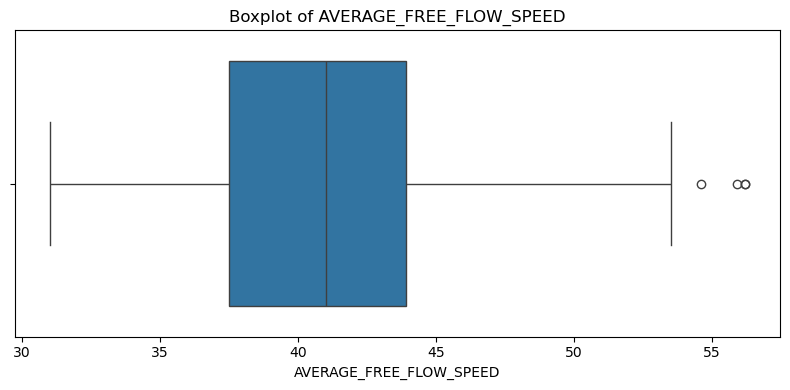

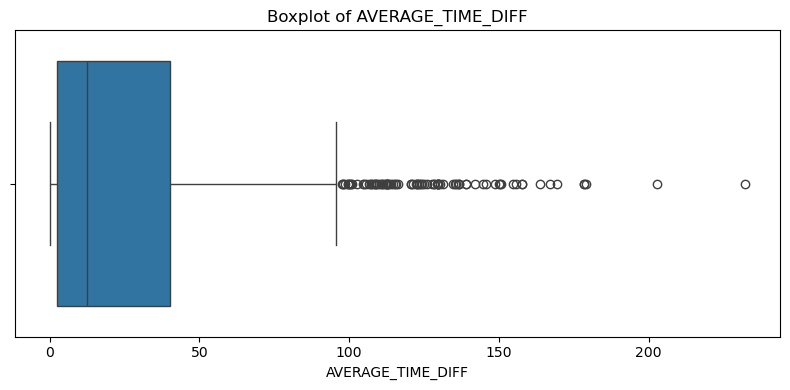

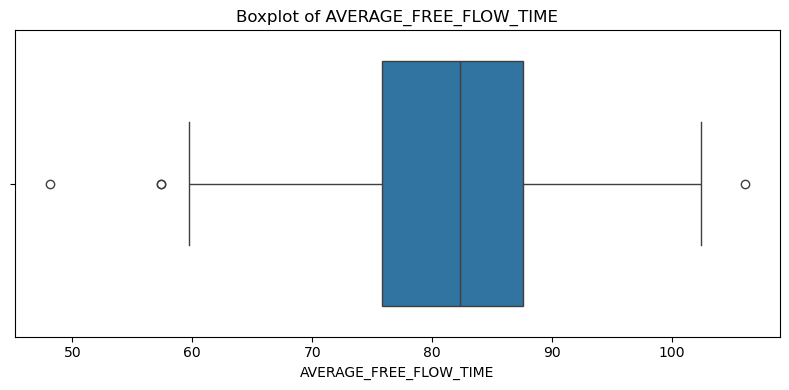

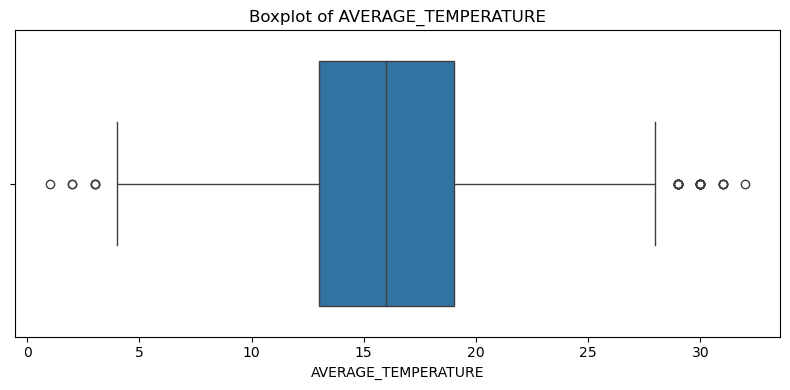

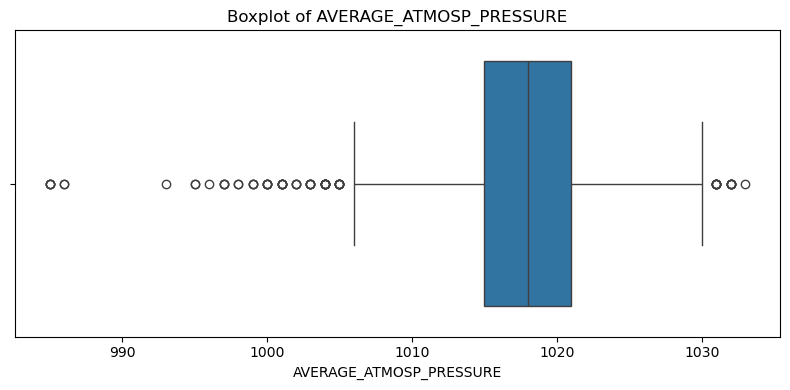

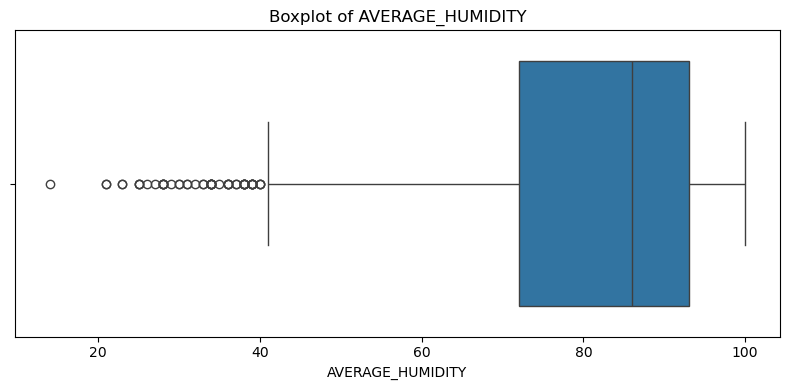

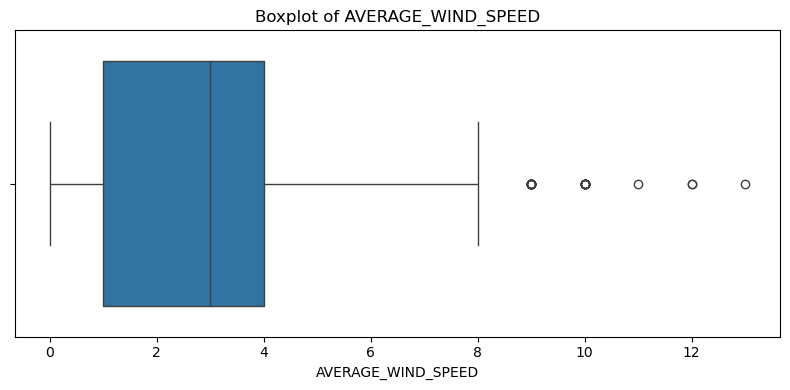

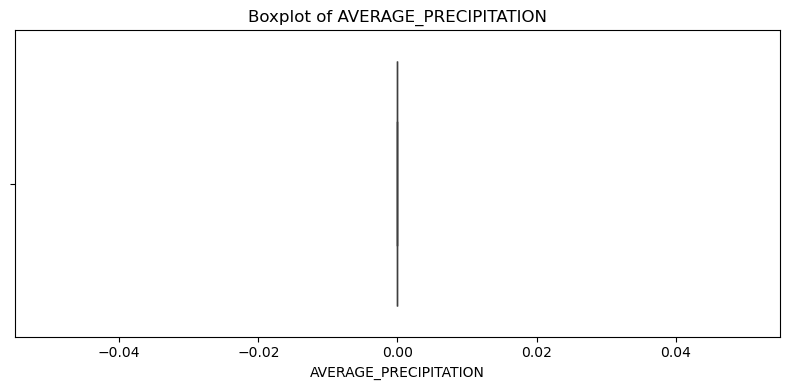

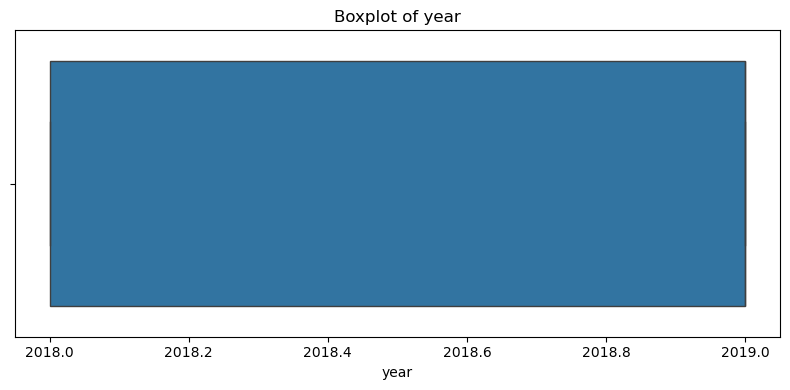

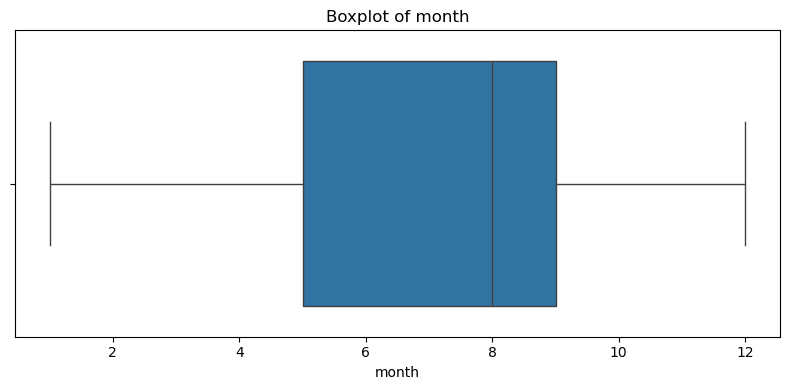

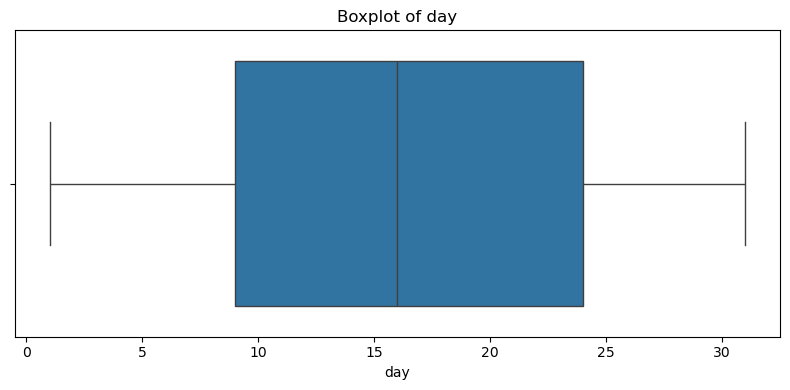

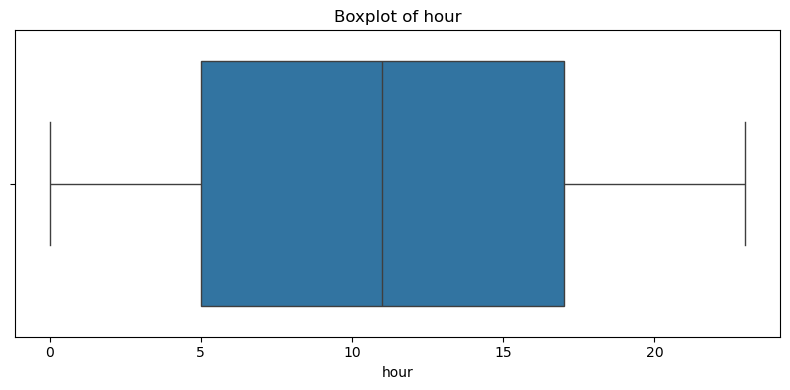

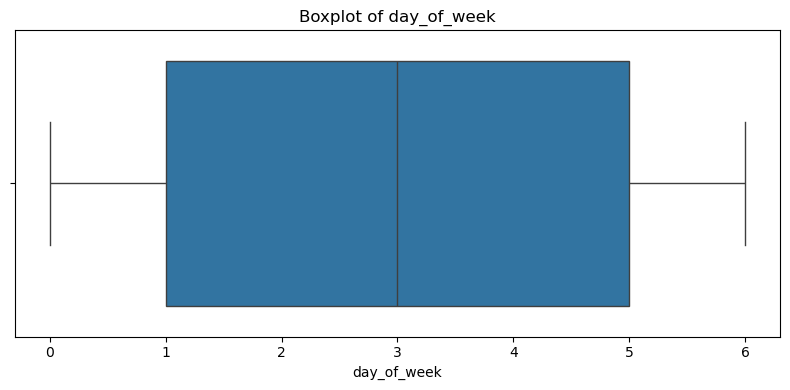

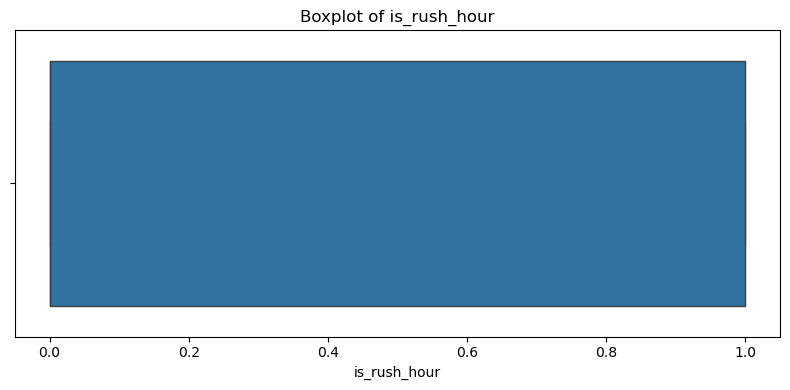

In [10]:
for col in dfTest.columns:
    if pd.api.types.is_numeric_dtype(dfTest[col]):
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=dfTest[col])
        plt.title(f'Boxplot of {col}')
        plt.tight_layout()
        plt.show()

In [11]:
dfTest.nunique()

city_name                     1
record_date                1500
AVERAGE_FREE_FLOW_SPEED     199
AVERAGE_TIME_DIFF           610
AVERAGE_FREE_FLOW_TIME      337
LUMINOSITY                    3
AVERAGE_TEMPERATURE          32
AVERAGE_ATMOSP_PRESSURE      42
AVERAGE_HUMIDITY             70
AVERAGE_WIND_SPEED           14
AVERAGE_CLOUDINESS            9
AVERAGE_PRECIPITATION         1
AVERAGE_RAIN                  9
year                          2
month                        12
day                          31
hour                         24
day_of_week                   7
is_rush_hour                  2
dtype: int64

In [12]:
dfTest.drop(columns=['AVERAGE_PRECIPITATION'], inplace=True)
dfTest.drop(columns=['city_name'], inplace=True)
dfTest.drop(columns=['year'], inplace=True)
dfTest.drop(columns=['month'], inplace=True)
dfTest.drop(columns=['day'], inplace=True)
dfTest.drop(columns=['hour'], inplace=True)
dfTest.drop(columns=['city_name'], inplace=True)

KeyError: "['city_name'] not found in axis"

In [ ]:
for col in dfTrain.columns:
    if pd.api.types.is_numeric_dtype(dfTrain[col]):
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=dfTrain[col])
        plt.title(f'Boxplot of {col}')
        plt.tight_layout()
        plt.show()

In [ ]:
dfTrain.nunique()

In [ ]:
dfTrain.drop(columns=['AVERAGE_PRECIPITATION'], inplace=True)
dfTrain.drop(columns=['city_name'], inplace=True)
dfTrain.drop(columns=['year'], inplace=True)
dfTrain.drop(columns=['month'], inplace=True)
dfTrain.drop(columns=['day'], inplace=True)
dfTrain.drop(columns=['hour'], inplace=True)
dfTrain.drop(columns=['city_name'], inplace=True)

In [ ]:
print(dfTest.duplicated().any())

In [ ]:
print(dfTrain.duplicated().any())

In [ ]:
print(dfTest.isna().any())

In [ ]:
print(dfTrain.isna().any())